In [1]:
import torch
import torch.nn as nn

In [ ]:
!pip install kornia
import kornia

**Double Convolution Layer**

In [3]:
class DoubleConv(nn.Module):
  def __init__(self,in_channels,out_channels):
    super().__init__()
    self.block=nn.Sequential(
        nn.Conv2d(in_channels,out_channels,kernel_size=3,padding=1,bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels,out_channels,kernel_size=3,padding=1,bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
    )

  def forward(self,x):
    return self.block(x)

**Encoding Block**

In [4]:
class EncodingBlock(nn.Module):
  def __init__(self,in_channels,out_channels):
    super().__init__()
    self.downBlock=DoubleConv(in_channels,out_channels)
    self.maxpool=nn.MaxPool2d(2)

  def forward(self,x):
    skip=self.downBlock(x)
    down=self.maxpool(skip)
    return (skip,down)

In [ ]:
Decoding Block

In [5]:
class DecodingBlock(nn.Module):
  def __init__(self,in_channels,skip_channels,out_channels):
    super().__init__()
    self.up=nn.ConvTranspose2d(in_channels,out_channels,kernel_size=2,stride=2)
    self.upBlock=DoubleConv(out_channels+skip_channels,out_channels)

  def forward(self,x,skip):
    x=self.up(x)
    x = torch.cat(
            [skip, x],
            dim=1
        )
    x=self.upBlock(x)
    return x


**U-Net Architecture**

In [6]:
class UNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.enc1=EncodingBlock(1,64)
    self.enc2=EncodingBlock(64,128)
    self.enc3=EncodingBlock(128,256)
    self.enc4=EncodingBlock(256,512)
    self.center=DoubleConv(512,1024)
    self.dec1=DecodingBlock(1024,512,512)
    self.dec2=DecodingBlock(512,256,256)
    self.dec3=DecodingBlock(256,128,128)
    self.dec4=DecodingBlock(128,64,64)
    self.final = nn.Conv2d(64,2,kernel_size=1)


  def forward(self,x):
    skip1,down1=self.enc1(x)
    skip2,down2=self.enc2(down1)
    skip3,down3=self.enc3(down2)
    skip4,down4=self.enc4(down3)
    down4=self.center(down4)
    dec1=self.dec1(down4,skip4)
    dec2=self.dec2(dec1,skip3)
    dec3=self.dec3(dec2,skip2)
    dec4=self.dec4(dec3,skip1)
    final=self.final(dec4)
    return final


In [7]:
model = UNet()

x = torch.randn(
    4,
    1,
    256,
    256
)

y = model(x)

print(y.shape)

torch.Size([4, 2, 256, 256])


In [8]:
import kagglehub

path = kagglehub.dataset_download(
    "rhtsingh/google-universal-image-embeddings-128x128"
)

path += "/128x128"

print("Dataset path:", path)

100%|██████████| 1.36G/1.36G [00:13<00:00, 106MB/s] 

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/rhtsingh/google-universal-image-embeddings-128x128/versions/1/128x128


In [10]:
###### Dataset LAB Utlities ######
from skimage import color
import numpy as np
def to_numpy(self,x):
    return x.detach().cpu().numpy()


def lab_rgb(L,ab):
  L=to_numpy(L)
  ab=to_numpy(ab)

  if L.ndim==3 and L.shape[0]==1:
    L=L.squeeze(0)
  if ab.shape[0]==2:
    ab=ab.transpose(1,2,0)

  L=np.array(L,dtype=np.float32)
  ab=np.array(ab,dtype=np.float32)

  lab=np.zeros((L.shape[0],L.shape[1],3),dtype=np.float32)
  lab[:,:,0]=L*100
  lab[:,:,1:]=ab*128

  rgb = color.lab2rgb(lab)
  rgb = np.clip(rgb, 0, 1)
  return rgb

def rgb_lab(img):
  if isinstance(img, torch.Tensor):
        img = img.numpy()

  lab=color.rgb2lab(img)
  L=lab[:,:,0]/100
  ab=lab[:,:,1:]/128
  L = torch.tensor(L).unsqueeze(0)
  AB = torch.tensor(
      AB.transpose(2,0,1)
  )
  return L.float(), AB.float()



In [11]:
# #### Dataset Preparation ####
# import os
# import torch
# from torchvision import transforms
# from torch.utils.data import DataLoader, random_split
# from PIL import Image
# from skimage import color
# class Lab_Dataset(torch.utils.data.Dataset):
#   def __init__(self,root_dir,transform):
#     self.image_paths=[]
#     for class_name in os.listdir(root_dir):
#       class_path=os.path.join(root_dir,class_name)
#       if not os.path.isdir(class_path):
#                 continue
#       for image_name in os.listdir(class_path):
#         self.image_paths.append(os.path.join(class_path,image_name))

#     self.transform = transform

#   def __getitem__(self, idx):
#         img_path = self.image_paths[idx]
#         img = Image.open(img_path).convert("RGB")

#         img = self.transform(img)
#         img_np = img.permute(1, 2, 0).numpy()


#         lab = color.rgb2lab(img_np).astype("float32")
#         L = lab[:, :, 0] / 100.0
#         ab = lab[:, :, 1:] / 128.0

#         L = torch.from_numpy(L).unsqueeze(0)
#         ab = torch.from_numpy(ab).permute(2, 0, 1)
#         return L, ab

#   def __len__(self):
#       return len(self.image_paths)



In [12]:
import os, torch
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
from PIL import Image

class Lab_Dataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, transform):
        self.image_paths = []
        for class_name in os.listdir(root_dir):
            class_path = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_path):
                continue
            for image_name in os.listdir(class_path):
                self.image_paths.append(os.path.join(class_path, image_name))
        self.transform = transform

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        return self.transform(img)          # (3, H, W) in [0,1]

    def __len__(self):
        return len(self.image_paths)

In [13]:

transform_resize = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

dataset = Lab_Dataset(
    root_dir=path,
    transform=transform_resize
)

train_size = int(0.9 * len(dataset))
test_size = len(dataset) - train_size
train_ds, test_ds = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, pin_memory=True,
                          num_workers=2, persistent_workers=True, prefetch_factor=4)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False, pin_memory=True,
                          num_workers=2, persistent_workers=True, prefetch_factor=4)

In [14]:
print(f"Number of training samples: {len(train_ds)}")
print(f"Number of test samples: {len(test_ds)}")

Number of training samples: 119275
Number of test samples: 13253


In [15]:
criterion = nn.MSELoss()

In [16]:
num_epochs = 20

In [18]:
import time
from tqdm import tqdm

device = "cuda"
model = UNet().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()
num_epochs = 20

scaler = torch.amp.GradScaler('cuda')

start_time = time.time()
best_loss = float('inf')

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch")
    for rgb in progress_bar:
        rgb = rgb.to(device, non_blocking=True)
        lab = kornia.color.rgb_to_lab(rgb)
        gray  = lab[:, 0:1] / 100.0
        color = lab[:, 1:3] / 128.0

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            output = model(gray)
            loss = criterion(output, color)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1} completed. Avg Loss: {total_loss/len(train_loader):.4f}")
    if total_loss < best_loss:
        best_loss = total_loss
        torch.save(model.state_dict(), 'best_colorization_model.pth')

mins, secs = divmod(time.time() - start_time, 60)
print(f"\nTraining completed in {int(mins)} minutes and {int(secs)} seconds.")

Epoch 1/20: 100%|██████████| 932/932 [13:07<00:00,  1.18batch/s, loss=0.00982]


Epoch 1 completed. Avg Loss: 0.0132


Epoch 2/20: 100%|██████████| 932/932 [13:12<00:00,  1.18batch/s, loss=0.00972]


Epoch 2 completed. Avg Loss: 0.0093


Epoch 3/20: 100%|██████████| 932/932 [13:14<00:00,  1.17batch/s, loss=0.00962]


...

Epoch 8 completed. Avg Loss: 0.0080


Epoch 9/20: 100%|██████████| 932/932 [13:25<00:00,  1.16batch/s, loss=0.00715]


Epoch 9 completed. Avg Loss: 0.0079


Epoch 10/20:   1%|          | 10/932 [00:09<14:41,  1.05batch/s, loss=0.00679]


KeyboardInterrupt: 

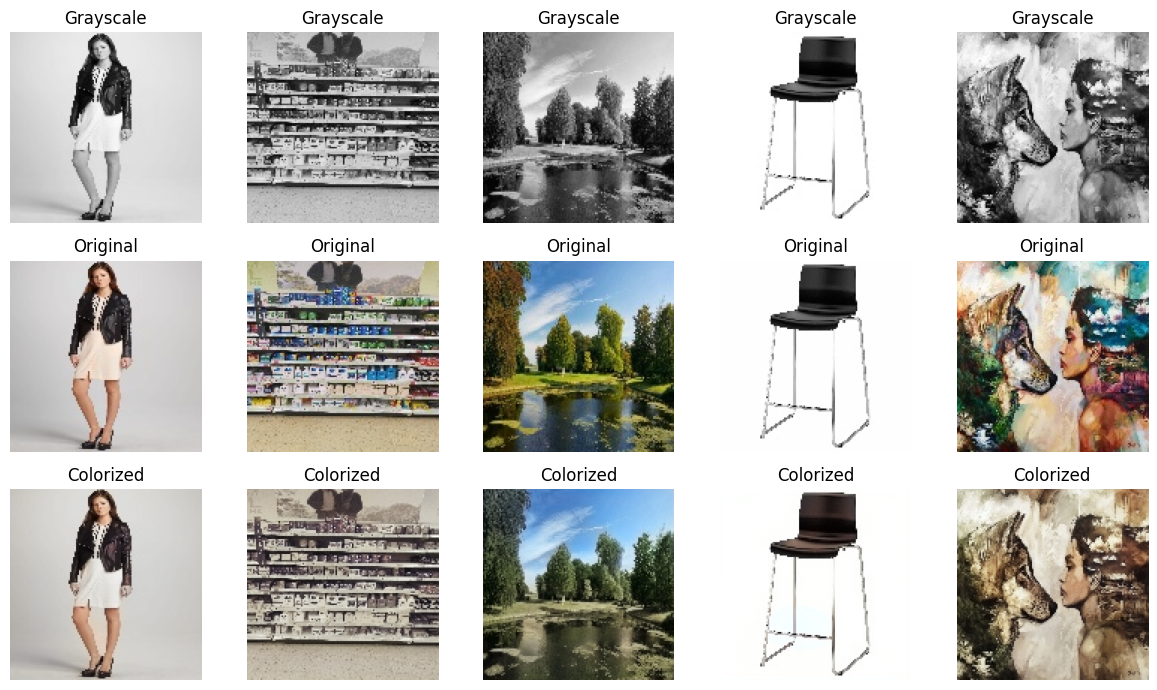

In [19]:
import matplotlib.pyplot as plt
import random

def to_rgb(L, ab):
    lab = torch.cat([L * 100.0, ab * 128.0], dim=1)
    rgb = kornia.color.lab_to_rgb(lab).clamp(0, 1)
    return rgb.squeeze(0).permute(1, 2, 0).cpu().numpy()

model.eval()
samples = random.sample(list(test_ds), 5)
plt.figure(figsize=(12, 7))
with torch.no_grad():
    for i, rgb in enumerate(samples):
        rgb = rgb.unsqueeze(0).to(device)
        lab = kornia.color.rgb_to_lab(rgb)
        L = lab[:, 0:1] / 100.0
        true_ab = lab[:, 1:3] / 128.0
        pred_ab = model(L)

        plt.subplot(3, 5, i + 1);  plt.imshow(L.squeeze().cpu(), cmap='gray'); plt.title("Grayscale"); plt.axis('off')
        plt.subplot(3, 5, i + 6);  plt.imshow(to_rgb(L, true_ab)); plt.title("Original");  plt.axis('off')
        plt.subplot(3, 5, i + 11); plt.imshow(to_rgb(L, pred_ab)); plt.title("Colorized"); plt.axis('off')
plt.tight_layout()
plt.show()

In [20]:
from google.colab import files
files.download('best_colorization_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>